# Libs

In [193]:
# https://www.kaggle.com/datasets/abdelrahmanahmed110/used-cars-for-sale-in-egypt/data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder, StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

# Dataset Details

In [194]:
data = pd.read_csv('hatla2ee_scraped_data.csv')
df = data.copy()
df.head()

,Name,Price,Color,Mileage,Make,Model,City,Date Displayed,Automatic Transmission,Air Conditioner,Power Steering,Remote Control,Item URL
0,Kia Sportage 2024,"2,800,000 EGP",Dark grey,300 Km,Kia,Sportage,Tagamo3 - New Cairo,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/kia/sportage/62...
1,Chery Arrizo 5 2022,NaN,Bronze,"86,000 Km",Chery,Arrizo 5,Nasr city,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/chery/Arrizo-5/...
2,Fiat Tipo 2021,"1,200,000 EGP",Petroleum,"131,000 Km",Fiat,Tipo,Kafr el-Dawwar,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/fiat/tipo/6286701
3,Hyundai Tucson Turbo GDI 2021,"2,050,000 EGP",Black,"125,000 Km",Hyundai,Tucson Turbo GDI,Nasr city,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/hyundai/Tucson-...
4,BMW X1 2018,"2,050,000 EGP",Gray,"84,000 Km",BMW,X1,Cairo,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/bmw/x1/6254123


In [195]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33559 entries, 0 to 33558
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Name                    33559 non-null  object
 1   Price                   32625 non-null  object
 2   Color                   33559 non-null  object
 3   Mileage                 31440 non-null  object
 4   Make                    33559 non-null  object
 5   Model                   33559 non-null  object
 6   City                    33559 non-null  object
 7   Date Displayed          33559 non-null  object
 8   Automatic Transmission  33559 non-null  object
 9   Air Conditioner         33559 non-null  object
 10  Power Steering          33559 non-null  object
 11  Remote Control          33559 non-null  object
 12  Item URL                33559 non-null  object
dtypes: object(13)
memory usage: 3.3+ MB


In [196]:
df.isnull().sum()

,0
Name,0
Price,934
Color,0
Mileage,2119
Make,0
Model,0
City,0
Date Displayed,0
Automatic Transmission,0
Air Conditioner,0


In [197]:
df.describe()

,Name,Price,Color,Mileage,Make,Model,City,Date Displayed,Automatic Transmission,Air Conditioner,Power Steering,Remote Control,Item URL
count,33559,32625,33559,31440,33559,33559,33559,33559,33559,33559,33559,33559,33559
unique,4158,828,24,1084,101,889,103,124,2,2,2,2,22048
top,Nissan Sunny 2022,"650,000 EGP",Black,"200,000 Km",Hyundai,Sunny,Cairo,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/chevrolet/lanos...
freq,647,969,6532,1317,3800,1868,3983,12333,21289,20643,18450,19263,289


# Missings and Duplicates

In [198]:
df.drop_duplicates(inplace=True)

In [199]:
# to remove EGP and KM from Price and Mileage
def clean_num(x):
    if type(x) == str:
        return float(x.split()[0].replace(',' , ''))
    else:
        return np.nan
df["Price"] = df["Price"].apply(clean_num)
df["Mileage"] = df["Mileage"].apply(clean_num)

df.head()

,Name,Price,Color,Mileage,Make,Model,City,Date Displayed,Automatic Transmission,Air Conditioner,Power Steering,Remote Control,Item URL
0,Kia Sportage 2024,2800000.0,Dark grey,300.0,Kia,Sportage,Tagamo3 - New Cairo,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/kia/sportage/62...
1,Chery Arrizo 5 2022,NaN,Bronze,86000.0,Chery,Arrizo 5,Nasr city,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/chery/Arrizo-5/...
2,Fiat Tipo 2021,1200000.0,Petroleum,131000.0,Fiat,Tipo,Kafr el-Dawwar,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/fiat/tipo/6286701
3,Hyundai Tucson Turbo GDI 2021,2050000.0,Black,125000.0,Hyundai,Tucson Turbo GDI,Nasr city,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/hyundai/Tucson-...
4,BMW X1 2018,2050000.0,Gray,84000.0,BMW,X1,Cairo,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/bmw/x1/6254123


In [200]:
print(len(df))

df = df.dropna(subset=['Price']).copy() # Remove missing targets and ensure it's a new copy
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median()) # Fill missing values with median

print(len(df))

22052
21981


In [201]:
df.isnull().sum() # GG =))

,0
Name,0
Price,0
Color,0
Mileage,0
Make,0
Model,0
City,0
Date Displayed,0
Automatic Transmission,0
Air Conditioner,0


#Feature Selection/Creation

In [202]:
df = df.drop('Item URL', axis=1) # mlo4 lazma
df.head()

,Name,Price,Color,Mileage,Make,Model,City,Date Displayed,Automatic Transmission,Air Conditioner,Power Steering,Remote Control
0,Kia Sportage 2024,2800000.0,Dark grey,300.0,Kia,Sportage,Tagamo3 - New Cairo,2024-02-16,Yes,Yes,Yes,Yes
2,Fiat Tipo 2021,1200000.0,Petroleum,131000.0,Fiat,Tipo,Kafr el-Dawwar,2024-02-16,Yes,Yes,Yes,Yes
3,Hyundai Tucson Turbo GDI 2021,2050000.0,Black,125000.0,Hyundai,Tucson Turbo GDI,Nasr city,2024-02-16,Yes,Yes,Yes,Yes
4,BMW X1 2018,2050000.0,Gray,84000.0,BMW,X1,Cairo,2024-02-16,Yes,Yes,Yes,Yes
5,Chevrolet Optra 2021,700000.0,Blue,75000.0,Chevrolet,Optra,Obour City,2024-02-16,Yes,Yes,Yes,Yes


#### Handle Date_Displayed Column and Date in Name Column

In [203]:
extracted_years = df['Name'].str.extract(r'((?:19|20)\d{2})', expand=False) # get model year from Name column.
df['Model_Year'] = pd.to_numeric(extracted_years, errors='coerce') # add it as a new column

In [204]:
df.isnull().sum()

,0
Name,0
Price,0
Color,0
Mileage,0
Make,0
Model,0
City,0
Date Displayed,0
Automatic Transmission,0
Air Conditioner,0


In [205]:
mode_model_year = int(df['Model_Year'].mode()[0])
df['Model_Year'] = df['Model_Year'].fillna(mode_model_year).astype(int)

In [206]:
df.isnull().sum() # a5yran

,0
Name,0
Price,0
Color,0
Mileage,0
Make,0
Model,0
City,0
Date Displayed,0
Automatic Transmission,0
Air Conditioner,0


### Create New Features Based Date


In [207]:
# Create Car_Age Feature
df['Date Displayed'] = pd.to_datetime(df['Date Displayed'])
df['Listing_Year'] = df['Date Displayed'].dt.year
df['Listing_Month'] = df['Date Displayed'].dt.month

df['Car_Age'] = df['Listing_Year'] - df['Model_Year']

### Drop Raw Data

In [208]:
cols_to_drop = ['Name', 'Date Displayed', 'Model_Year']
df = df.drop(columns=cols_to_drop)

df

,Price,Color,Mileage,Make,Model,City,Automatic Transmission,Air Conditioner,Power Steering,Remote Control,Listing_Year,Listing_Month,Car_Age
0,2800000.0,Dark grey,300.0,Kia,Sportage,Tagamo3 - New Cairo,Yes,Yes,Yes,Yes,2024,2,0
2,1200000.0,Petroleum,131000.0,Fiat,Tipo,Kafr el-Dawwar,Yes,Yes,Yes,Yes,2024,2,3
3,2050000.0,Black,125000.0,Hyundai,Tucson Turbo GDI,Nasr city,Yes,Yes,Yes,Yes,2024,2,3
4,2050000.0,Gray,84000.0,BMW,X1,Cairo,Yes,Yes,Yes,Yes,2024,2,6
5,700000.0,Blue,75000.0,Chevrolet,Optra,Obour City,Yes,Yes,Yes,Yes,2024,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31734,560000.0,White,127000.0,Chery,Arrizo 5,El Haram,Yes,Yes,Yes,Yes,2024,2,4
31735,860000.0,Red,7000.0,Nissan,Sunny,Heliopolis,Yes,Yes,Yes,Yes,2024,2,0
31736,1000000.0,Blue,250000.0,Brilliance,V5,Tagamo3 - New Cairo,Yes,Yes,Yes,Yes,2024,2,11
31737,3650000.0,Black,11000.0,BMW,320,Cairo,Yes,Yes,Yes,Yes,2024,2,1


In [209]:
df.describe()
# car_age min value is -1???????
# min price is 1060 gneh???????????

,Price,Mileage,Listing_Year,Listing_Month,Car_Age
count,2.198100e+04,2.198100e+04,21981.000000,21981.000000,21981.000000
mean,8.477219e+05,1.345936e+05,2023.473318,6.616623,10.140940
std,9.321061e+05,8.537281e+04,0.499299,4.899566,8.802931
min,1.060000e+03,0.000000e+00,2023.000000,1.000000,-1.000000
25%,3.600000e+05,7.300100e+04,2023.000000,2.000000,3.000000
50%,6.150000e+05,1.270000e+05,2023.000000,10.000000,8.000000
75%,9.500000e+05,1.850000e+05,2024.000000,11.000000,14.000000
max,2.000000e+07,2.226000e+06,2024.000000,12.000000,60.000000


In [210]:
df.loc[df['Car_Age'] < 0, 'Car_Age'] = 0

df = df[df['Price'] > 50000]
df = df[df['Price'] < 10000000]

df.describe()

,Price,Mileage,Listing_Year,Listing_Month,Car_Age
count,2.172300e+04,2.172300e+04,21723.000000,21723.000000,21723.000000
mean,8.449656e+05,1.347525e+05,2023.474750,6.603738,9.836671
std,8.477467e+05,8.564825e+04,0.499374,4.900290,8.268424
min,5.200000e+04,0.000000e+00,2023.000000,1.000000,0.000000
25%,3.700000e+05,7.300000e+04,2023.000000,2.000000,3.000000
50%,6.200000e+05,1.270000e+05,2023.000000,10.000000,8.000000
75%,9.500000e+05,1.860000e+05,2024.000000,11.000000,14.000000
max,9.800000e+06,2.226000e+06,2024.000000,12.000000,60.000000


# Skewed Data

In [211]:
df['Price'] = np.log1p(df['Price'])
df['Mileage'] = np.log1p(df['Mileage'])

# Split


### Binary Mapping On Binary Columns First


In [212]:
binary_cols = ['Automatic Transmission', 'Air Conditioner', 'Power Steering', 'Remote Control']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

### Splitting

In [213]:
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [214]:
X.describe()

,Mileage,Automatic Transmission,Air Conditioner,Power Steering,Remote Control,Listing_Year,Listing_Month,Car_Age
count,21723.000000,21723.000000,21723.000000,21723.000000,21723.000000,21723.000000,21723.000000,21723.000000
mean,11.395439,0.605763,0.601482,0.521061,0.548497,2023.474750,6.603738,9.836671
std,1.561118,0.488697,0.489604,0.499568,0.497654,0.499374,4.900290,8.268424
min,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000,1.000000,0.000000
25%,11.198228,0.000000,0.000000,0.000000,0.000000,2023.000000,2.000000,3.000000
50%,11.751950,1.000000,1.000000,1.000000,1.000000,2023.000000,10.000000,8.000000
75%,12.133507,1.000000,1.000000,1.000000,1.000000,2024.000000,11.000000,14.000000
max,14.615717,1.000000,1.000000,1.000000,1.000000,2024.000000,12.000000,60.000000


In [215]:
X

,Color,Mileage,Make,Model,City,Automatic Transmission,Air Conditioner,Power Steering,Remote Control,Listing_Year,Listing_Month,Car_Age
0,Dark grey,5.707110,Kia,Sportage,Tagamo3 - New Cairo,1,1,1,1,2024,2,0
2,Petroleum,11.782960,Fiat,Tipo,Kafr el-Dawwar,1,1,1,1,2024,2,3
3,Black,11.736077,Hyundai,Tucson Turbo GDI,Nasr city,1,1,1,1,2024,2,3
4,Gray,11.338584,BMW,X1,Cairo,1,1,1,1,2024,2,6
5,Blue,11.225257,Chevrolet,Optra,Obour City,1,1,1,1,2024,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...
31734,White,11.751950,Chery,Arrizo 5,El Haram,1,1,1,1,2024,2,4
31735,Red,8.853808,Nissan,Sunny,Heliopolis,1,1,1,1,2024,2,0
31736,Blue,12.429220,Brilliance,V5,Tagamo3 - New Cairo,1,1,1,1,2024,2,11
31737,Black,9.305741,BMW,320,Cairo,1,1,1,1,2024,2,1


# Encoding


In [216]:
# based on the num of unique values h5tar el encoding technique
print(df.info())
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
Index: 21723 entries, 0 to 31738
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price                   21723 non-null  float64
 1   Color                   21723 non-null  object 
 2   Mileage                 21723 non-null  float64
 3   Make                    21723 non-null  object 
 4   Model                   21723 non-null  object 
 5   City                    21723 non-null  object 
 6   Automatic Transmission  21723 non-null  int64  
 7   Air Conditioner         21723 non-null  int64  
 8   Power Steering          21723 non-null  int64  
 9   Remote Control          21723 non-null  int64  
 10  Listing_Year            21723 non-null  int32  
 11  Listing_Month           21723 non-null  int32  
 12  Car_Age                 21723 non-null  int64  
dtypes: float64(2), int32(2), int64(5), object(4)
memory usage: 2.2+ MB
None
Price                   

In [217]:
print(X_train.shape)
print(X_train.columns)
print(len(X_train.columns))
print(f"Number of unique colors {len(X_train['Color'].unique())}")

(17378, 12)
Index(['Color', 'Mileage', 'Make', 'Model', 'City', 'Automatic Transmission',
       'Air Conditioner', 'Power Steering', 'Remote Control', 'Listing_Year',
       'Listing_Month', 'Car_Age'],
      dtype='object')
12
Number of unique colors 24


### Encoding (OneHot, target)

`target_type="continuous"` for target encoding as `Price` Dtype is `float64`




In [218]:
cols_one_hot = ['Color']
cols_target  = ['Make', 'Model', 'City']

preprocessor = ColumnTransformer(
  transformers=[
        ('one_hot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cols_one_hot),
        ('target_enc', TargetEncoder(smooth='auto', target_type="continuous", random_state=42), cols_target)
    ],
    remainder='passthrough'
)


In [219]:
X_train = preprocessor.fit_transform(X_train, y_train)
X_test  = preprocessor.transform(X_test)

print("New Shape:", X_train.shape)

New Shape: (17378, 34)


# Scaling

Used `RobustScaler` because Mileage column was skewed.

In [220]:
# (Handles outliers better than StandardScaler)
scaler = RobustScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

In [221]:
X_train

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
        -1.        ,  0.        ],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.22222222,  0.09090909],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.11111111,  0.36363636],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
        -1.        , -0.54545455],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
        -0.88888889,  0.09090909],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  1.36363636]])

# Random Forest Regression

In [222]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_rf)

R2 = r2_score(y_test_original, y_pred_original)
MAE = mean_absolute_error(y_test_original, y_pred_original)
RMSE = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

# Visualization

----Random Forest Regrssion----
R-squared score: 0.8304
Mean Absolute Error (MAE): 151,624 EGP
Root Mean Squared Error (RMSE): 348,532 EGP


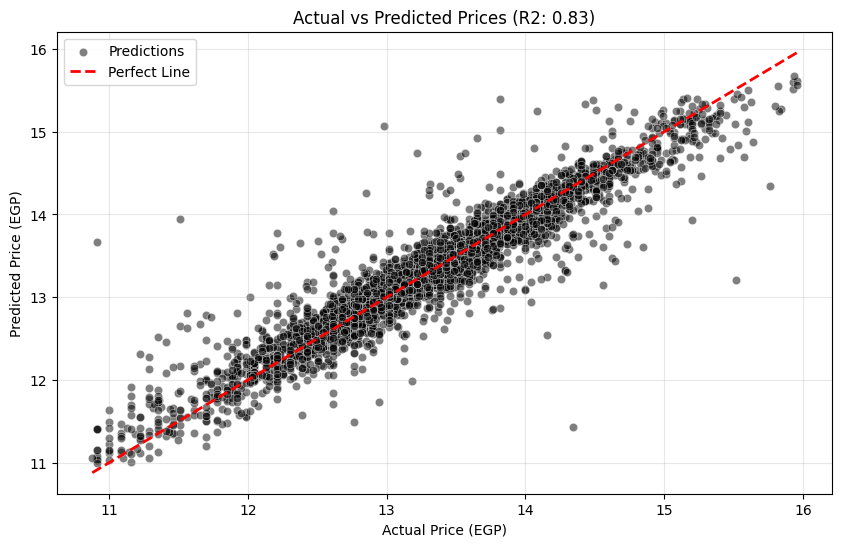

In [223]:
print("----Random Forest Regrssion----")
print(f"R-squared score: {R2:.4f}")
print(f"Mean Absolute Error (MAE): {MAE:,.0f} EGP")
print(f"Root Mean Squared Error (RMSE): {RMSE:,.0f} EGP")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, color='black', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Line')

plt.xlabel('Actual Price (EGP)')
plt.ylabel('Predicted Price (EGP)')
plt.title(f'Actual vs Predicted Prices (R2: {R2:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('random_forest_predictions.png')
plt.show()

In [224]:
def predict_from_input():
    n_Make = input("Enter Car Make: ").strip()
    n_Model = input("Enter Car Model: ").strip()
    n_Color = input("Enter Car Color: ").strip()
    n_City = input("Enter City: ").strip()
    n_year_of_make = int(input("Enter Car Made Year: "))
    n_Listing_Year = int(input("Enter Car Listing Year: "))
    n_Listing_Month = int(input("Enter Car Listing Month: "))
    n_Mileage = float(input("Enter Mileage in KM: "))

    print("-" * 20)
    is_automatic = input("Is it Automatic Transmission? (y/n): ").lower()
    is_air = input("Has Air Conditioner? (y/n): ").lower()
    is_power = input("Has Power Steering? (y/n): ").lower()
    is_remote = input("Has Remote Control? (y/n): ").lower()


    car_age = n_Listing_Year - n_year_of_make

    def get_binary(val):
        return 1 if val == 'y' else 0

    data = {
        'Color': [n_Color],
        'Mileage': [n_Mileage],
        'Make': [n_Make],
        'Model': [n_Model],
        'City': [n_City],
        'Automatic Transmission': [get_binary(is_automatic)],
        'Air Conditioner': [get_binary(is_air)],
        'Power Steering': [get_binary(is_power)],
        'Remote Control': [get_binary(is_remote)],
        'Listing_Year': [n_Listing_Year],
        'Listing_Month': [n_Listing_Month],
        'Car_Age': [car_age]
    }

    new_df = pd.DataFrame(data)

    new_df = new_df[X.columns]

    new_df_enc = preprocessor.transform(new_df)
    new_df_scaled = scaler.transform(new_df_enc)

    price = rf_model.predict(new_df_scaled)[0]

    print("\n" + "="*40)
    print(f"Predicted Price: {price:,.0f} EGP")
    print("="*40)

predict_from_input()